In [1]:
%%capture
!pip install osmnx
!pip install geopandas

#!pip install dask_geopandas
!pip install branca;
!pip install folium;
!pip install mapclassify;
!pip install h3;
!pip install h3pandas;

In [2]:
from matplotlib import cm
import seaborn as sns
import numpy as np
from matplotlib import pyplot as plt
from pathlib import Path

import h3pandas

import osmnx as ox
import pandas as pd
import dask.dataframe as dd
from dask.diagnostics import ProgressBar
import matplotlib.dates as mdates
import geopandas as gpd
from shapely.geometry import Point
from shapely.ops import unary_union

import matplotlib as mpl

import folium
import branca.colormap as cmbranca

mpl.rcParams["axes.spines.top"] = False
mpl.rcParams["axes.spines.right"] = False
mpl.rcParams["legend.frameon"] = False

pd.set_option("display.max_columns", None)


def coefficient_of_variation(data):
    data = np.array(data)
    mean = np.mean(data)
    if mean == 0:
        return np.nan  # Avoid division by zero
    std_dev = np.std(data, ddof=1)  # sample standard deviation
    cv = (std_dev / mean) * 100
    return cv


def plot_map_gdf(gdf, col, log_transform=True, figsize=(10, 10),
    cmap="Blues", alpha=1, ax=None, fig=None, th=0,
    show_cbar=True, vmin=None, vmax=None):

    # Filter data
    plot_gdf = gdf[gdf[col] > th].copy()

    # Apply transformation
    if log_transform:
        plot_gdf["_plot_val"] = np.log10(1 + plot_gdf[col])
        label = f"log10(1 + {col})"
        transform = lambda x: np.log10(1 + x)
    else:
        plot_gdf["_plot_val"] = plot_gdf[col]
        label = col
        transform = lambda x: x

    values = plot_gdf["_plot_val"]

    # Create figure/axis if needed
    if ax is None and fig is None:
        fig, ax = plt.subplots(figsize=figsize)

    # Determine coherent vmin/vmax in transformed space
    if vmin is None:
        vmin_plot = values.min()
    else:
        vmin_plot = transform(vmin)

    if vmax is None:
        vmax_plot = values.max()
    else:
        vmax_plot = transform(vmax)

    # Plot map using SAME normalization
    plot_gdf.plot(
        column="_plot_val",
        cmap=cmap,
        legend=False,
        ax=ax,
        alpha=alpha,
        vmin=vmin_plot,
        vmax=vmax_plot,
    )

    cbar = None

    # Create matching colorbar
    if show_cbar:
        norm = plt.Normalize(vmin=vmin_plot, vmax=vmax_plot)
        sm = cm.ScalarMappable(cmap=cmap, norm=norm)
        sm._A = []

        cbar = fig.colorbar(sm, ax=ax, fraction=0.015, pad=0.1, orientation="horizontal",)
        cbar.set_label(label)

    return fig, ax, cbar    



def plot_time_series(df_plot, axes=None, color="k", plot_avg=False, label=""):
    
    if axes is None:
        fig, axes = plt.subplots(nrows=3, ncols=1, figsize=(10, 10), sharex=False)

    axes[0].plot(df_plot["date"], df_plot["n_points_count"], c=color, linewidth=1, label=label, marker=".")
    if plot_avg:
        axes[0].axhline(np.mean(df_plot["n_points_count"]), c=color, linewidth=1, linestyle=":")
    axes[0].set_ylabel("# points", weight=600);
    
    axes[1].plot(df_plot["date"], df_plot["uid_unique"], c=color, linewidth=1, marker=".")
    if plot_avg:
        axes[1].axhline(np.mean(df_plot["uid_unique"]), c=color, linewidth=1, linestyle=":")
    axes[1].set_ylabel("# unique users", weight=600);
    
    axes[2].plot(df_plot["date"], df_plot["hex_id_unique"], c=color, linewidth=1, marker=".")
    if plot_avg:
        axes[2].axhline(np.mean(df_plot["hex_id_unique"]), c=color, linewidth=1, linestyle=":")
    axes[2].set_ylabel("# unique hexes", weight=600);
    
    for ax in axes:
        ax.tick_params(axis='x', labelsize=8)
        # Set major ticks every 2 days
        ax.xaxis.set_major_locator(mdates.DayLocator(interval=2))
        # Optional: format how the date appears
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))

    return axes


def fill_time_gaps(x, y, freq="D"):
    # convert to pandas objects
    x = pd.to_datetime(x)
    y = np.asarray(y)

    # build series
    s = pd.Series(y, index=x)

    # full date range
    full_index = pd.date_range(start=s.index.min(),end=s.index.max(),freq=freq)

    # reindex -> missing dates become NaN
    s_filled = s.reindex(full_index)

    return s_filled.index, s_filled.values


In [3]:
import h3
from shapely.geometry import shape

In [4]:
def gdf_to_h3(gdf, resolution):
    """
    Convert a GeoDataFrame of polygons to Uber H3 cells at a given resolution.
    """
    # ensure in lat/lon
    gdf = gdf.to_crs(epsg=4326)

    # collect unique H3 cell ids covering all input geometries
    h3_ids = set()
    for geom in gdf.geometry:
        cells = h3.geo_to_cells(geom, resolution)
        h3_ids.update(cells)

    # convert H3 cells to geojson‑style and then to Shapely polygons
    hex_geoms = []
    hex_ids = []
    for h in h3_ids:
        # cells_to_geo returns a __geo_interface__‑like dict for the cell(s)
        geojson = h3.cells_to_geo([h])
        # shape(...) converts geojson dict to shapely geometry
        poly = shape(geojson)
        hex_geoms.append(poly)
        hex_ids.append(h)

    # make GeoDataFrame
    h3_gdf = gpd.GeoDataFrame(
        {"h3_index": hex_ids},
        geometry=hex_geoms,
        crs="EPSG:4326"
    )

    return h3_gdf

In [5]:
def min_max_normalize_range(data, new_min=0, new_max=1):
    min_val = min(data)
    max_val = max(data)
    
    if max_val == min_val:
        return [new_min for _ in data]
    
    return [
        new_min + (x - min_val) * (new_max - new_min) / (max_val - min_val)
        for x in data
    ]

# Urban Activity Dynamics During 2023 Heatwaves in Manila

In this case study, we apply our methodology to anonymized mobility data from Veraset to assess the impact of a climate shock, specifically an extreme heatwave, on urban activity patterns. Understanding how populations move and use urban spaces during extreme heat provides insights into behavioral adaptation, infrastructure resilience, and urban climate vulnerability.
We focus on a series of **heatwave days in late April 2023** (i.e., April 20, 21, 23, 28, and 30) that affected **Manila (Philippines)**. Using the **Urban Space Usage Index**, we quantify deviations from typical activity patterns and examine how urban areas respond to this climate shock.

In [6]:
# Look at the heatwaves file for 2023

df_hw = pd.read_csv("./aux_data/daily_termperature_pasig_2015_2024(in).csv", parse_dates=["Date"])
df_hw = df_hw.drop(["Unnamed: 0"], axis=1)
df_hw['month'] = df_hw['Date'].dt.month
df_hw['day'] = df_hw['Date'].dt.day
df_hw['year'] = df_hw['Date'].dt.year

df_hw = df_hw[df_hw['year']==2023]

df_hw[:1]

,Date,MaxTemp_daily,MeanTemp_daily,MinTemp_daily,MaxTemp_baseline,MeanTemp_baseline,MinTemp_baseline,Threshold,Heatwave_Day,Heatwave_Rolling,month,day,year
2742,2023-01-01,29.437744,27.128662,25.712402,30.159387,27.340753,24.849268,33.159387,False,False,1,1,2023


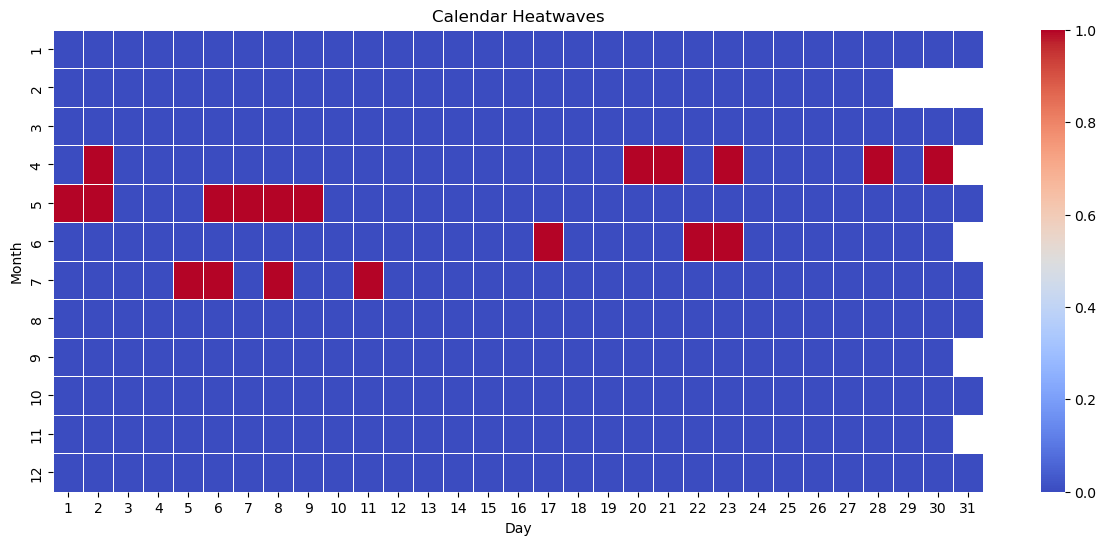

In [7]:
# plot the heatwaves "calendar"

matrix = df_hw.pivot_table(index='month', columns='day', values="Heatwave_Day", aggfunc='mean')
plt.figure(figsize=(15, 6))
sns.heatmap(matrix, cmap='coolwarm', linewidths=0.5)

plt.xlabel("Day")
plt.ylabel("Month")
plt.title("Calendar Heatwaves")

plt.show()

Text(0, 0.5, 'Temperature')

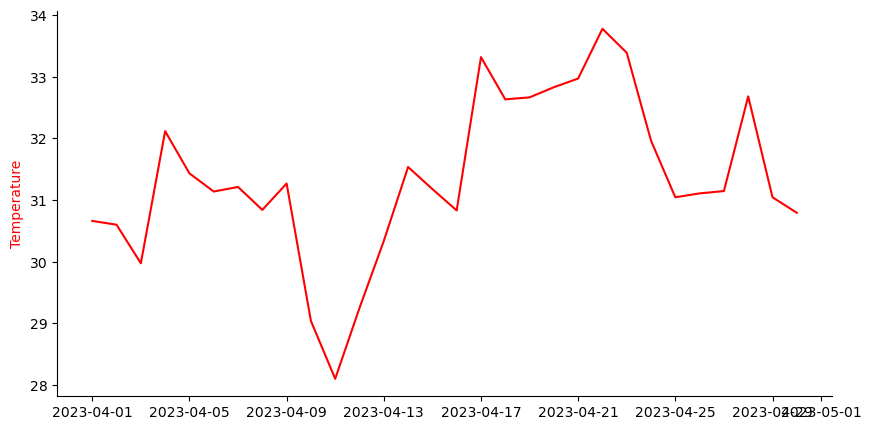

In [8]:
fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(10, 5), sharex=False)
x = pd.date_range(start="2023-04-01", end="2023-04-30", freq="D")
list_temperature = list(df_hw[df_hw["month"]==6]["MaxTemp_daily"])

plt.plot(x, list_temperature, color="red")
ax.set_ylabel("Temperature", color="red")

## 1. Data

### 1.1 Mobility Dataset
The analysis is based on the **[Veraset Movement dataset](https://docs.datapartnership.org/partners/veraset/examples/veraset.html)**, provided by Veraset as part of the Mobility Data collection from the Development Data Partnership. The dataset consists of anonymized mobile device location pings collected via a network of mobile applications and software development kits (SDKs). Each record includes geographic coordinates, a timestamp, and an anonymized device identifier. These data provide large-scale observations of human mobility, enabling the analysis of spatial and temporal patterns of urban activity.

In [9]:
SCENARIO = "HW_APR"
H3_res = 8

dataset_name = "dataset_heatwave_APR"
FROM_DATE = pd.to_datetime("2023-04-01")
TO_DATE = pd.to_datetime("2023-04-30")

### 1.2 Area of Interest (AOI)

The analysis focuses on the metropolitan area of Manila (Metro Manila), the capital region of the Philippines. The study area is defined using administrative boundaries extracted from OpenStreetMap (OSM) (Figure 1).

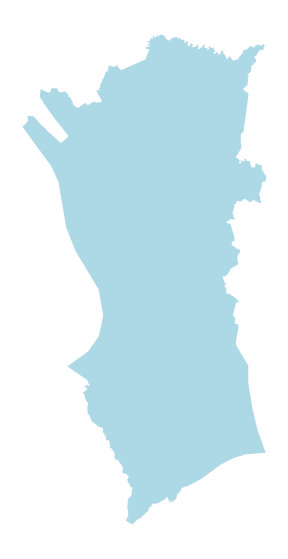

In [10]:
# AOI

gdf_AOI = gpd.read_file("./shape_files/shape_metro_manila.gpkg")

minx, miny, maxx, maxy = gdf_AOI.total_bounds
fig, ax = plt.subplots(figsize=(5,7))
gdf_AOI.plot(ax=ax, color='lightblue', edgecolor=None)
ax.axis("off");

**Figure 1.** Administrative boundary of the metropolitan area of Manila (Metro Manila), used to define the area of interest (AOI). All mobility data are spatially clipped to this region and aggregated using the H3 hierarchical grid system.

**Create (or load, if exists) the H3 spatial tessellation of the AOI**

| Res | Average Hexagon Area (km²) |
|-----|----------------------------|
| ... | ...                        |
| 6   | 36.129062164               |
| 7   | 5.161293360                |
| 8   | 0.737327598                |
| 9   | 0.105332513                |
| ... | ...                        |

In [11]:
SCENARIO = "HW_APR"
H3_res = 8

In [12]:
output_path = Path(f"./spatial_tessellations/gdf_h3_res8_manila.gpkg")

if output_path.exists():
    print("File exists. Loading...")
    gdf_h3 = gpd.read_file(output_path)
else:
    print("File not found. Computing and saving...")
    crs = gdf_AOI.crs
    gdf_h3 = gdf_to_h3(
        gdf_AOI.buffer(0.03).to_crs(crs),
        H3_res
    )
    print(len(gdf_h3))
    output_path.parent.mkdir(parents=True, exist_ok=True)
    gdf_h3.to_file(output_path, driver="GPKG")

File exists. Loading...


We spatially discretized the area of interest using the H3 Uber hierarchical indexing at resolution 8, corresponding to hexagonal cells of approximately 0.737 km². Each H3 cell (or hexagon) represents the spatial unit of the analysis.

<Axes: >

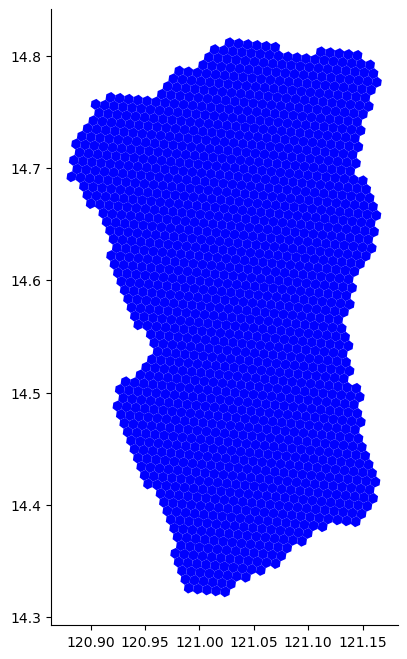

In [13]:
fig, ax = plt.subplots(figsize=(8,8))
gdf_h3.plot(color="blue", ax=ax, label="new")

In [ ]:
#gdf_h3 = gpd.read_file("./spatial_tessellations/H3_tess_turkey_res7.gpkg", layer="H3_tess")

### 1.3 Time window and study periods

To capture mobility and activity dynamics associated with extreme heat, we extract data for the period April 3-30, 2023, spatially clipped to the study area.

We define two analysis periods:
- **Baseline period**: April 3-11*
- **Event period**:  heatwave days, namely April 20, 21, 23, 28, and 30.

The extracted dataset consists of approximately **102 million GPS points** generated by **994,400 unique users**.

\* We exclude the period 12-19 April from the baseline, as it is associated with anomalously high activity levels (see Figure 3), likely driven by exogenous events. Including these days would bias the baseline and inflate Z-score magnitudes; therefore, they are omitted to ensure a more stable and representative reference period.

In [ ]:
time_window = pd.date_range(start=FROM_DATE, end=TO_DATE, freq="D")

# Print summary
print(f"Loading data from {min(time_window):%Y-%m-%d} to {max(time_window):%Y-%m-%d}")
print(f"Time window length: {len(time_window)} days")

### Data Loading

In [14]:
dataset_name = SCENARIO

path_base = f"s3://wbgggscecovid19dev-mobility/veraset/country=PH"
base_path_save = f"s3://wbgggscecovid19dev-mobility/proposals/561/datasets/"
path_save = f'{base_path_save}{dataset_name}/'

print(path_save)

s3://wbgggscecovid19dev-mobility/proposals/561/datasets/HW_APR/


#### Raw-Data Preparation and Loading (slow)

_loading time $\approx$ XXX mins for 90 days_

Load from scratch the dataset covering the baseline, event, and recovery periods using **Dask**.  
Apply spatial filtering to reduce the dataset to the Area of Interest (AOI).  
If the filtered subset is small enough to fit in memory, convert it to **Pandas** for faster aggregation and analysis.

In [ ]:
FROM_DATE = 
TO_DATE = 

In [ ]:
%%time

# -------------------------
# 0. Load raw GPS dataset (lazy)
columns = ['uid', 'datetime', 'hex_id', 'latitude', 'longitude']
ddf = dd.read_parquet(paths_to_load,  columns=columns, storage_options={"profile": "ECA"})

# 1. Bounding box filter
ddf = ddf[(ddf.longitude >= minx) & (ddf.longitude <= maxx) &
    (ddf.latitude  >= miny) & (ddf.latitude  <= maxy)]

# -------------------------
# 2. Process datetime (lazy)
ddf['local_datetime'] = (
    dd.to_datetime(ddf['datetime'], utc=True)
      .dt.tz_convert('Asia/Manila')
      .dt.tz_localize(None)
)

# re-add this
ddf = ddf[(ddf['local_datetime'] >= FROM_DATE) & (ddf['local_datetime'] <= TO_DATE + pd.Timedelta(days=1))]
ddf['date'] = ddf['local_datetime'].dt.floor('D')

In [ ]:
with ProgressBar():
    df = ddf.compute()

#### Hybrid

In [ ]:
with ProgressBar():
    df = ddf.compute()

df = df[df["date"]<=max(time_window)]

print("# rows:", len(df))

# Memory usage
mem_bytes = df.memory_usage(deep=True).sum()
mem_gb = mem_bytes / (1024**3)
print(f"{mem_gb:.2f} GB")

# Save the dataset for future (faster) loading
ddf_to_save = dd.from_pandas(df)
ddf_to_save.to_parquet(path_save,
                       write_index=False,
                       engine="pyarrow",
                       storage_options= {'profile':'ECA'})

#### Full dask

In [ ]:
with ProgressBar():
    ddf.to_parquet(
            path_save,
            write_index=False,
            engine="pyarrow",
            storage_options={'profile': 'ECA'}
        )

In [ ]:
!aws s3 ls --profile ECA s3://wbgggscecovid19dev-mobility/proposals/561/datasets/

___

#### Load pre-computed Dataset (fast)

_loading time $\approx$ 2 min for pre-computed 30 days_

In [15]:
paths_to_load = ["s3://wbgggscecovid19dev-mobility/proposals/561/datasets/dataset_heatwave_APR/*.parquet"]

In [16]:
ddf = dd.read_parquet(paths_to_load, engine="pyarrow", storage_options={"profile": "ECA"}, columns=["uid", "latitude", "longitude", "date"])
ddf = ddf.repartition(partition_size="200MB")

with ProgressBar():
    df = ddf.compute()

[########################################] | 100% Completed | 173.63 s
[########################################] | 100% Completed | 144.75 s


In [17]:
# Basic cleaning and memory stats

df = df[["uid", "latitude", "longitude", "date"]]

print("# rows:", len(df))
print("# users:", df["uid"].nunique())
# Memory usage
mem_bytes = df.memory_usage(deep=True).sum()
mem_gb = mem_bytes / (1024**3)
print(f"{mem_gb:.2f} GB")

# rows: 115322928
# users: 1081725
10.34 GB


In [18]:
# Set the desired H3 Spatial resolution

lat = df["latitude"].to_numpy()
lng = df["longitude"].to_numpy()

list_h3_cell_ids = [h3.latlng_to_cell(lat[i], lng[i], H3_res) for i in range(len(lat))]

In [19]:
df["hex_id"] = list_h3_cell_ids
del list_h3_cell_ids

#### Spatial Filtering

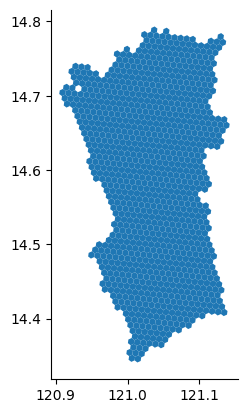

In [20]:
gdf_h3_AOI = gpd.sjoin(gdf_h3, gdf_AOI, how="inner", predicate="intersects")
gdf_h3_AOI.plot();

In [21]:
gdf_h3_AOI[:1]

,h3_index,geometry,index_right
1,88694ed6e7fffff,"POLYGON ((121.08143 14.77176, 121.07758 14.774...",0


In [22]:
# set-based filtering
set_h3_AOI = set(gdf_h3_AOI["h3_index"])
df_AOI = df[df["hex_id"].isin(set_h3_AOI)]

Visualize the map **BEFORE** and **AFTER** the spatial filtering

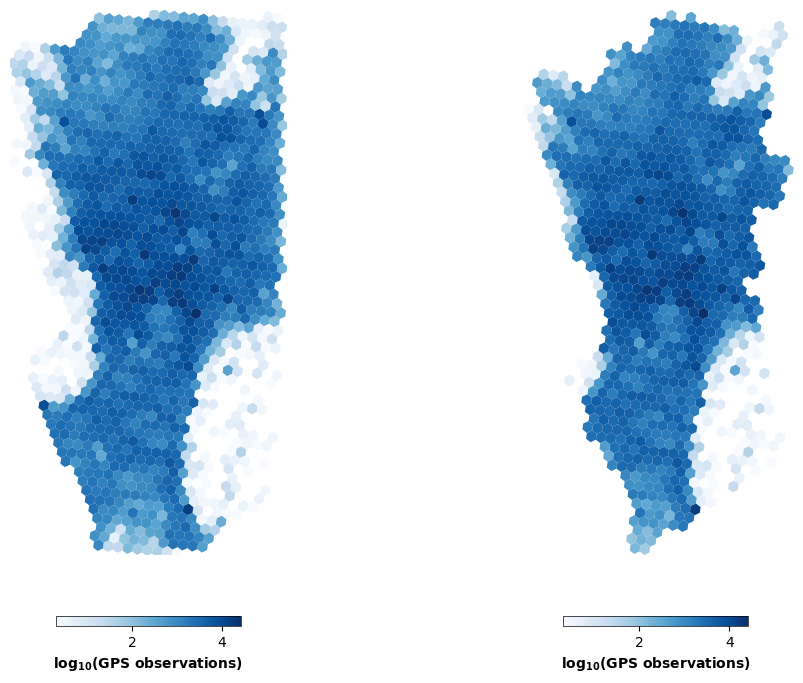

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(12,8))

# Get global bounds from the full hex grid
xmin, ymin, xmax, ymax = gdf_h3_AOI.total_bounds

for ax, dplot in zip(axes, [df, df_AOI]):
    df_gb_count = dplot.groupby(["hex_id", "date"], as_index=False).count()[["hex_id", "uid"]]
    df_hex_avg_points_day = df_gb_count.groupby("hex_id", as_index=False).mean()
    gdf_map = gdf_h3.merge(df_hex_avg_points_day, left_on="h3_index", right_on="hex_id", how="left")
    gdf_map["uid"] = gdf_map["uid"].fillna(0)
    _, _, cbar = plot_map_gdf(gdf_map, col="uid", cmap="Blues", ax=ax, fig=fig)
    
    ax.axis("off");
    ax.set_xlim(xmin, xmax)
    ax.set_ylim(ymin, ymax)

    cbar.set_label(r"$\mathbf{log_{10}}$(GPS observations)", weight=600)
    cbar.outline.set_linewidth(0.5) 

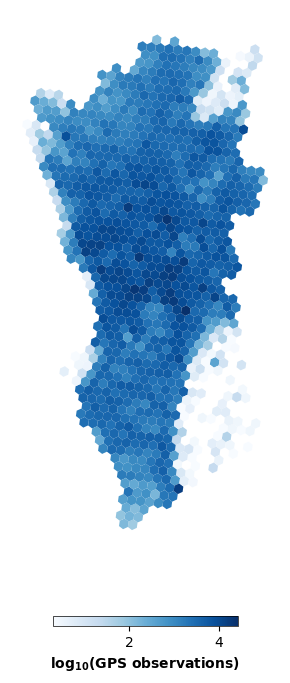

In [24]:
fig, ax = plt.subplots(1, 1, figsize=(12,8))


df_gb_count = df_AOI.groupby(["hex_id", "date"], as_index=False).count()[["hex_id", "uid"]]
df_hex_avg_points_day = df_gb_count.groupby("hex_id", as_index=False).mean()
gdf_map = gdf_h3.merge(df_hex_avg_points_day, left_on="h3_index", right_on="hex_id", how="left")
gdf_map["uid"] = gdf_map["uid"].fillna(0)
_, _, cbar = plot_map_gdf(gdf_map, col="uid", cmap="Blues", ax=ax, fig=fig)

ax.axis("off");
#ax.set_xlim(xmin, xmax)
#ax.set_ylim(ymin, ymax)

cbar.set_label(r"$\mathbf{log_{10}}$(GPS observations)", weight=600)
cbar.outline.set_linewidth(0.5) 

**Figure 2.** Spatial distribution of GPS observations shown as the average number of records per H3 hexagon (resolution 8). Higher values represent a greater concentration of recorded activity. The color scale is log₁₀-transformed, with darker blue tones indicating areas with more observations.

In [25]:
df_AOI = df_AOI[["uid", "hex_id", "date"]]

print("# rows:", len(df_AOI))
print("# users:", df_AOI["uid"].nunique())
# Memory usage
mem_bytes = df_AOI.memory_usage(deep=True).sum()
mem_gb = mem_bytes / (1024**3)
print(f"{mem_gb:.2f} GB")

# rows: 102968007
# users: 994409
14.59 GB


In [26]:
#del df
import gc
gc.collect()

5831

In [27]:
del df_gb_count

In [28]:
gc.collect()

0

### 1.4 Preprocessing and filtering

To ensure data quality and reduce noise, we apply a set of preprocessing steps. Users with very low daily activity (fewer than eight recorded points per day) are excluded, as they do not provide reliable information on spatial behavior. In addition, H3 hexagons are retained only if they are consistently active throughout the observation period. Hexes with insufficient activity are removed to avoid unstable estimates and inflated Z-scores.

The final dataset consists of 97,484,716 observations from 611,809 users covering 847 spatial units.


In [ ]:
# Time series: Total Points, Unique Users, and Visited Hexes per Day

df_gb_stats_raw = (
    df_AOI.groupby("date")
      .agg(n_points_count=("uid", "count"), uid_unique=("uid", "nunique"),
           hex_id_unique=("hex_id", "nunique")).reset_index())

In [ ]:
axes_ts = plot_time_series(df_gb_stats_raw, axes=None, color="k", plot_avg=False)
for ax in axes_ts:
    ax.xaxis.set_major_locator(mdates.DayLocator(interval=7))
    ax.set_xlabel("Date", weight=600)
    ax.set_xlim(None, pd.to_datetime("2023-04-30"))

In [ ]:
list_gps_user_day = list(df_AOI.groupby(['uid', 'date']).size().reset_index(name='n_obs')["n_obs"])

print("--- Number of observations per user per day ---")
print("avg. ", round(np.mean(list_gps_user_day),2))
print("Q1", np.quantile(list_gps_user_day, .25))
print("median", np.quantile(list_gps_user_day, .5))
print("Q3", np.quantile(list_gps_user_day, .75))

In [ ]:
fig, ax = plt.subplots(figsize=(4, 4))

sns.kdeplot(list_gps_user_day, clip=[0, None], c="k", linewidth=1)

p25 = np.quantile(list_gps_user_day, 0.25)
p50 = np.quantile(list_gps_user_day, 0.5)
p75 = np.quantile(list_gps_user_day, 0.75)

for p, label in zip([p25, p50, p75], ["25th", "50th", "75th"]):
    plt.axvline(p, c="grey", linestyle="--", linewidth=1)
    # Annotate the percentile near the line
    plt.text(p, plt.ylim()[1], f"{label}", rotation=0, color='k', fontsize=8)

plt.xscale("log")
ax.set_xlabel("Number of observations / day", weight=600)
ax.set_ylabel("Density", weight=600);

In [ ]:
%%time

fig, axes = plt.subplots(nrows=3, ncols=1, figsize=(10, 10), sharex=False)

_ = plot_time_series(df_gb_stats_raw, axes=axes, color="k", plot_avg=False, label="raw")

user_min_points = [3, 7, 8]#[2, 3, 5, 10]

palette = sns.color_palette("viridis", n_colors=len(user_min_points))

for user_th, col in zip(user_min_points, palette):

    df_filtered_u = df_AOI[df_AOI.groupby(['uid', 'date'])['uid'].transform('count') >= user_th]
    
    df_gb_stats_filtered = (
    df_filtered_u.groupby("date")
              .agg(
                  n_points_count=("uid", "count"),uid_unique=("uid", "nunique"),
                  hex_id_unique=("hex_id", "nunique")).reset_index())

    del df_filtered_u
    _ = plot_time_series(df_gb_stats_filtered, axes=axes, color=col,
                         plot_avg=False, label=f"U >= {user_th} points")
    '''
    print(f"CV users with >= {user_th} points")
    print("Points: ", coefficient_of_variation(df_gb_stats_filtered["n_points_count"]))
    print("Users: ", coefficient_of_variation(df_gb_stats_filtered["uid_unique"]))
    print("Hexes: ", coefficient_of_variation(df_gb_stats_filtered["hex_id_unique"]))
    print()
    '''

axes[0].legend()

for ax in axes:
    ax.xaxis.set_major_locator(mdates.DayLocator(interval=7))
    ax.set_xlabel("Date", weight=600)
    ax.set_xlim(None, pd.to_datetime("2023-04-30"))

## 2. Methods

The analysis follows the methodological framework described in {doc}`Methodology` and applied in the previous case study. In brief, we use the **Urban Space Usage Index** ($I$), defined as the **share of unique users visiting each H3 hexagon**. The number of unique users is used as a proxy for human presence, under the assumption that higher user counts correspond to greater spatial utilization.

To **quantify deviations** from typical conditions, we compute **Z-scores**, which measure how strongly observed activity deviates from baseline levels. Positive values indicate higher activity, while negative values indicate lower activity compared to baseline conditions.

**Filter 1:** Remove users per day who do not meet the minimum number of GPS points threshold (noise users).

In [29]:
# filtering parameters

# tip: we can use the median value, it seems robust to me
min_points_per_day = 8

df_filtered_u = df_AOI[df_AOI.groupby(['uid', 'date'])['uid'].transform('count') >= min_points_per_day]

print(f"min points/day: {min_points_per_day}")
print(f"# GPS points: {len(df_filtered_u)} ({len(df_AOI)-len(df_filtered_u)} points removed)")
print("# unique users", df_filtered_u["uid"].nunique())

min points/day: 8
# GPS points: 97642022 (5325985 points removed)
# unique users 613146


Compute the Urban Space Index
- each **row** is an **hex**
- each **column** refers to a **day**
- each cell is the number of unique users that visit an hex on a given day (ACTIVITY)

In [30]:
ts_ACTIVITY = df_filtered_u.groupby(["hex_id", "date"])["uid"].nunique().unstack(fill_value=0)
ts_ACTIVITY[:3]

date,2023-04-01,2023-04-02,2023-04-03,2023-04-04,2023-04-05,2023-04-06,2023-04-07,2023-04-08,2023-04-09,2023-04-10,2023-04-11,2023-04-12,2023-04-13,2023-04-14,2023-04-15,2023-04-16,2023-04-17,2023-04-18,2023-04-19,2023-04-20,2023-04-21,2023-04-22,2023-04-23,2023-04-24,2023-04-25,2023-04-26,2023-04-27,2023-04-28,2023-04-29,2023-04-30
hex_id,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
88694e5201fffff,13,8,4,6,3,5,2,4,2,3,3,5,10,6,17,15,14,13,11,6,9,2,15,13,12,15,10,27,35,36
88694e5203fffff,240,165,154,108,121,75,125,99,95,159,115,209,228,388,640,552,504,485,378,247,209,313,284,254,407,420,411,621,731,695
88694e5205fffff,7,7,3,7,7,2,7,3,5,6,5,7,4,9,15,15,12,18,8,4,8,8,14,17,18,21,24,34,41,34



Filter 2: Remove hexes that do not meet the minimum activity threshold across a sufficient share of days.

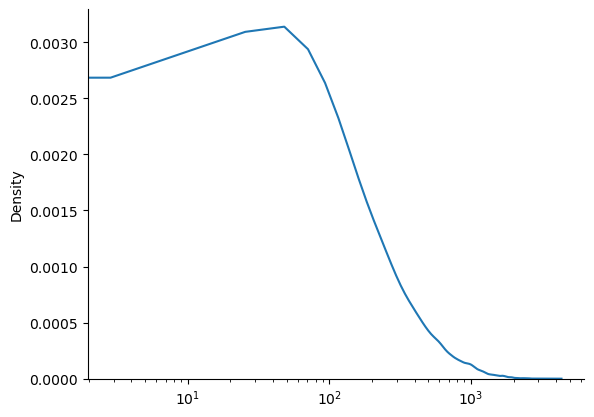

In [31]:
values_list = ts_ACTIVITY.to_numpy().ravel().tolist()
sns.kdeplot(values_list)
plt.xscale("log")

In [32]:
k = 0                   # minimum observations per day
x_percent = 0.95        # e.g., x% of days required

# total number of days (columns)
total_days = ts_ACTIVITY.shape[1]

# minimum number of valid days required
min_days_required = x_percent * total_days

# count how many days per hex exceed k
valid_days_per_hex = (ts_ACTIVITY > k).sum(axis=1)

# filter
hexes_to_keep = set(ts_ACTIVITY[valid_days_per_hex >= min_days_required].index)
ts_ACTIVITY_filtered = ts_ACTIVITY[ts_ACTIVITY.index.isin(hexes_to_keep)]

print("total number of hexes:", len(ts_ACTIVITY_filtered))
print("removed hexes:", len(ts_ACTIVITY) - len(ts_ACTIVITY_filtered))

total number of hexes: 847
removed hexes: 117


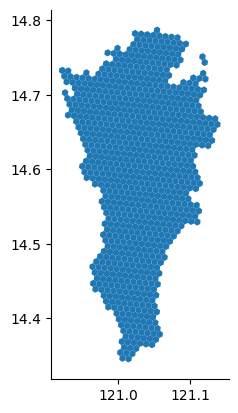

In [33]:
gdf_h3[gdf_h3["h3_index"].isin(ts_ACTIVITY_filtered.index)].plot()
ax.axis("off");

In [34]:
G = set(ts_ACTIVITY_filtered.index)

In [35]:
len(df_filtered_u[df_filtered_u["hex_id"].isin(G)])

97484716

In [36]:
df_filtered_u[df_filtered_u["hex_id"].isin(G)]["uid"].nunique()

611809

In [37]:
df_filtered_u[df_filtered_u["hex_id"].isin(G)]["hex_id"].nunique()

847

**Compute the number of unique users that visit an hex on a given day (to normalize ACTIVITY)**

In [38]:
total_unique_users = df_filtered_u.groupby("date")["uid"].nunique()
ts_USI = ts_ACTIVITY_filtered / total_unique_users

ts_USI[:1]

date,2023-04-01,2023-04-02,2023-04-03,2023-04-04,2023-04-05,2023-04-06,2023-04-07,2023-04-08,2023-04-09,2023-04-10,2023-04-11,2023-04-12,2023-04-13,2023-04-14,2023-04-15,2023-04-16,2023-04-17,2023-04-18,2023-04-19,2023-04-20,2023-04-21,2023-04-22,2023-04-23,2023-04-24,2023-04-25,2023-04-26,2023-04-27,2023-04-28,2023-04-29,2023-04-30
hex_id,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
88694e5201fffff,0.000411,0.000267,0.00013,0.000169,0.000086,0.000208,0.000075,0.000178,0.0001,0.00009,0.000122,0.000124,0.000222,0.000111,0.000264,0.000257,0.000219,0.000203,0.000196,0.000118,0.000153,0.00004,0.000286,0.000184,0.000138,0.000167,0.000109,0.000147,0.00022,0.000226


In [39]:
ts_USI = ts_USI.loc[:, "2023-04-03":]

## 3. Results

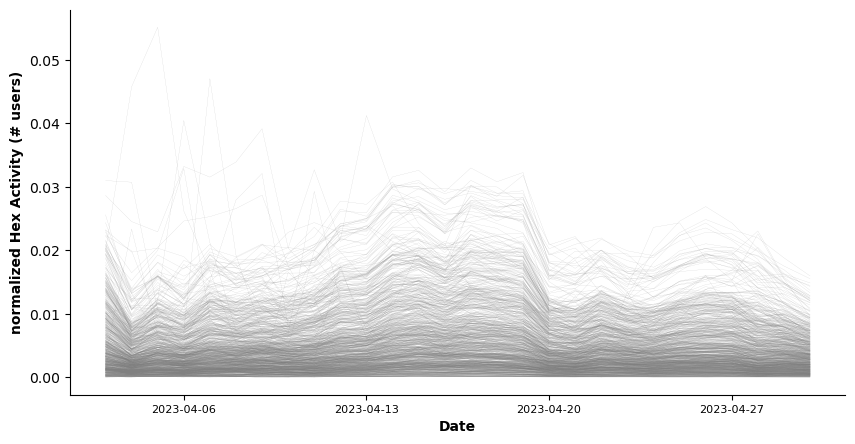

In [40]:
fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(10, 5), sharex=False)

for hex_id in ts_USI.index:
    ax.plot(ts_USI.columns, ts_USI.loc[hex_id], alpha=0.6, linewidth=0.1, color="grey")

ax.tick_params(axis='x', labelsize=8)
ax.xaxis.set_major_locator(mdates.DayLocator(interval=7))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
ax.set_xlabel("Date", weight=600)
ax.set_ylabel("normalized Hex Activity (# users)", weight=600);
#plt.ylim(0, 200);

### 3.1 Temporal evolution of urban activity

The temporal evolution of the Urban Space Usage Index ($I$) shows relatively stable activity levels during the baseline period (April 3-11), with moderate day-to-day variability (Figure 3). A distinct increase in activity is observed between April 12 and 19 (highlighted in red), indicating a temporary deviation from typical conditions. To ensure a stable and representative baseline, we exclude this period, as the elevated activity levels, likely driven by specific events, would bias the reference distribution and inflate Z-score magnitudes. 
A clear decrease in activity is observed on the first heatwave day (April 20), when activity drops below the baseline average. All heatwave days (marked as red stars) are associated with below-average activity levels, indicating a consistent reduction in urban space usage during periods of extreme heat.

Interestingly, activity remains suppressed not only during heatwave days but also in the intervening days between close heatwave events. While partial recovery is observed on non-heatwave days, activity levels generally remain below or close to the baseline mean.

In [41]:
HW_days = ["2023-04-20" ,"2023-04-21" ,"2023-04-23" ,"2023-04-28" ,"2023-04-30"]

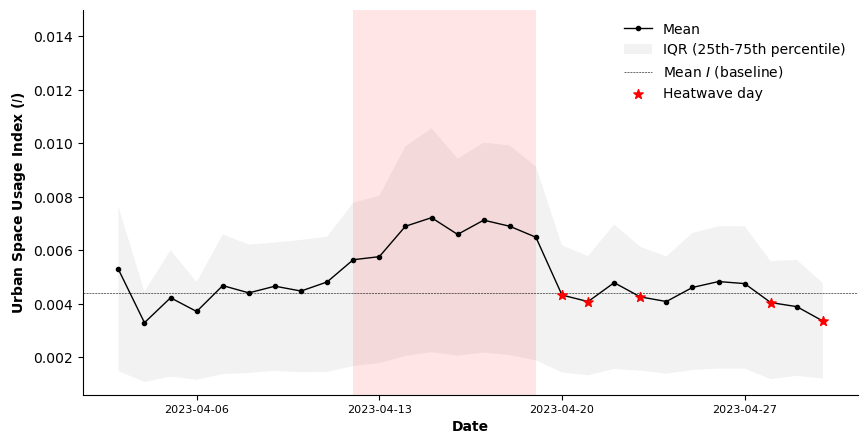

In [42]:
# Calculate the mean and IQR
mean_values = ts_USI.mean(axis=0)
q25 = ts_USI.quantile(0.25, axis=0)
q75 = ts_USI.quantile(0.75, axis=0)

# Create the plot
fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(10, 5), sharex=False)

# Plot the mean line
ax.plot(ts_USI.columns, mean_values, c="k", label="Mean", linewidth=1, marker=".")

# Plot the shaded area for the IQR
ax.fill_between(ts_USI.columns, q25, q75, color="grey", alpha=0.1, label="IQR (25th-75th percentile)", edgecolor="none")

ax.axhline(ts_USI.loc[:, "2023-04-03":"2023-04-11"].mean().mean(), color="k", linewidth=0.4, linestyle="--", label="Mean $I$ (baseline)")

#ax.axvspan(pd.to_datetime("2023-04-05 00:00"), pd.to_datetime("2023-04-11 00:00"), color="blue", alpha=0.1, linewidth=0)
ax.axvspan(pd.to_datetime("2023-04-12 00:00"), pd.to_datetime("2023-04-19 00:00"), color="red", alpha=0.1, linewidth=0)


# Highlight the heatwave days
hw_dates = pd.to_datetime(HW_days)
hw_y_values = ts_USI[hw_dates].mean().values
ax.scatter(hw_dates, hw_y_values, marker="*", color="red", s=50, zorder=99, label="Heatwave day")


# Format the x-axis (dates)
ax.tick_params(axis='x', labelsize=8)
ax.xaxis.set_major_locator(mdates.DayLocator(interval=7))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
ax.set_xlabel("Date", weight=600)
ax.set_ylabel("Urban Space Usage Index ($I$)", weight=600)

ax.set_ylim(None, 0.015)

# Add a legend
ax.legend();

**Figure 3.** Time series of the median Urban Space Usage Index ($I$) across all hexagonal cells in the area of interest, with the shaded area representing the interquartile range. Red stars indicate heatwave days, while the shaded red area represents the period excluded from the baseline.

### 3.2 Anomaly detection


To assess whether observed changes correspond to statistically significant deviations from typical conditions, we use the **Z-score**, which measures how many standard deviations observed activity deviates from its baseline.

During the baseline period, Z-scores exhibit some variability, with slightly negative values in the early days followed by stabilization closer to zero (Figure 4). This reflects moderate fluctuations in activity even under typical conditions.

Among the five heatwave days, **three exhibit negative Z-scores** (-0.20, -0.41, and -0.79 for April 21, 28, and 30, respectively), indicating reduced activity relative to baseline levels. The remaining two days show small positive deviations (0.13 and 0.30 for April 20 and 23, respectively), suggesting that the overall impact on aggregate activity is **limited in magnitude**.

On average, heatwave days have a Z-score of **-0.19**, compared to **0.40** for non-heatwave days in the same post-baseline period. To assess whether this difference is statistically significant, we compare heatwave and non-heatwave days from April 20 onward. We test the null hypothesis ($H_0$) that both sets of days are drawn from the same distribution, against the alternative hypothesis ($H_1$) that heatwave days exhibit lower Z-scores, using a significance level of $\alpha = 0.05$.

A one-sided [Mann-Whitney U test](https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.mannwhitneyu.html) indicates that heatwave days have **significantly lower Z-scores** than non-heatwave days (p = 0.041). This result is further supported by an exact [permutation test](https://docs.scipy.org/doc/scipy-1.16.2/reference/generated/scipy.stats.permutation_test.html), which compares the observed mean Z-score of heatwave days against all possible combinations of five days from the same sample (p = 0.03).

These results suggest that heatwave conditions are associated with a **systematic but modest reduction in activity** relative to contemporaneous non-heatwave days, consistent with their nature as **non-disruptive events**. Sensitivity analysis using alternative baseline periods yields consistent results, with similar Mann–Whitney and permutation test outcomes, confirming that the observed reduction is **robust to baseline selection**.


In [45]:
baseline = ts_USI.loc[:, "2023-04-03":"2023-04-11"]

baseline_mean = baseline.mean(axis=1)
baseline_std = baseline.std(axis=1)

In [59]:
# subtraction and division row-wise to compute the z-score

z_scores = ts_USI.sub(baseline_mean, axis=0).div(baseline_std, axis=0)
z_scores = z_scores.dropna()


z_scores = z_scores.loc[:, "2023-04-03":]
#z_scores.mean()

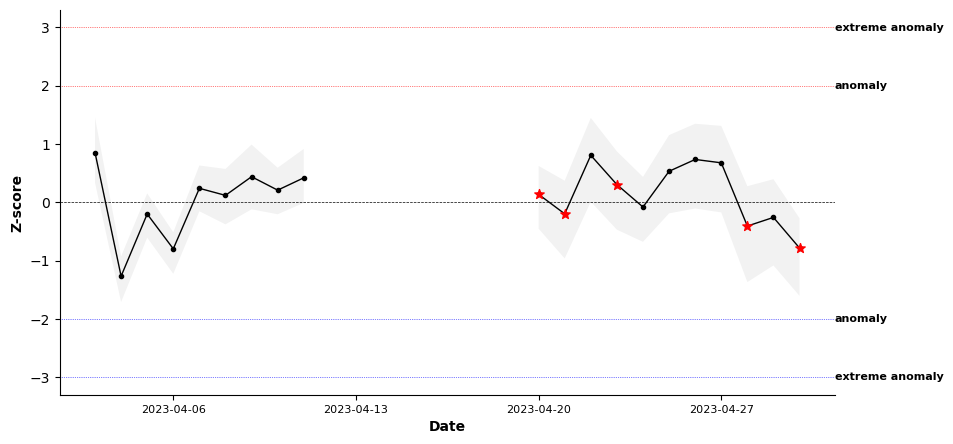

In [60]:
z_score_filter_start = pd.to_datetime("2023-04-12")
z_score_filter_end = pd.to_datetime("2023-04-19")

z_scores = z_scores.loc[:, ~z_scores.columns.to_series().between(z_score_filter_start, z_score_filter_end)]

mean_values = z_scores.mean(axis=0)
x_ax = z_scores.columns
x_ax, mean_values = fill_time_gaps(z_scores.columns, mean_values)

_, q25 = fill_time_gaps(z_scores.columns, z_scores.quantile(0.25, axis=0))
_, q75 = fill_time_gaps(z_scores.columns, z_scores.quantile(0.75, axis=0))

# Create the plot
fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(10, 5), sharex=False)

# Plot the mean line
ax.plot(x_ax, mean_values, c="k", linewidth=1, zorder=99, marker=".")  # average line

# Plot the shaded area for the IQR with no border
ax.fill_between(x_ax, q25, q75, color="grey", alpha=0.1, edgecolor="none", label="IQR (25th-75th percentile)")

# Add horizontal line at 0
ax.axhline(0, c="k", linewidth=.5, linestyle="--")

x_lims = ax.set_xlim()

# --- Anomaly thresholds ---
for anomaly_th, anomaly_label in zip([2, 3], ["anomaly", "extreme anomaly"]):
    ax.axhline(anomaly_th, c="red", linewidth=.5, linestyle=":")
    ax.axhline(-anomaly_th, c="blue", linewidth=.5, linestyle=":")
    
    # Adding labels for anomalies
    plt.text(x_lims[1], anomaly_th, anomaly_label, ha="left", va="center", weight=600, size=8)
    plt.text(x_lims[1], -anomaly_th, anomaly_label, ha="left", va="center", weight=600, size=8)
    
    

# Format the x-axis (dates)
ax.tick_params(axis='x', labelsize=8)
ax.xaxis.set_major_locator(mdates.DayLocator(interval=7))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
ax.set_xlabel("Date", weight=600)
ax.set_ylabel("Z-score", weight=600)


# Highlight the heatwave days
hw_dates = pd.to_datetime(HW_days)
hw_y_values = z_scores[hw_dates].mean().values
ax.scatter(hw_dates, hw_y_values, marker="*", color="red", s=50, zorder=99, label="Heatwave day");

#plt.ylim(-4, 4);

**Figure 4.** Time series of the average Z-score of the Urban Space Usage Index across hexagons in Metro Manila, with the shaded area representing the interquartile range. Horizontal dashed lines indicate anomaly thresholds. The missing segment corresponds to observations excluded from the baseline due to elevated activity.

In [61]:
A = z_scores.mean(axis=0).reset_index()
A[A["date"].isin(HW_days)]

,date,0
9,2023-04-20,0.134489
10,2023-04-21,-0.198760
12,2023-04-23,0.302495
17,2023-04-28,-0.408587
19,2023-04-30,-0.785511


In [62]:
df_hw[df_hw["Date"].isin(HW_days)].sort_values("Date")[["Date", "MeanTemp_daily", "MaxTemp_daily"]]

,Date,MeanTemp_daily,MaxTemp_daily
2851,2023-04-20,30.144226,33.358887
2852,2023-04-21,30.196899,33.278564
2854,2023-04-23,29.889465,33.173584
2859,2023-04-28,29.803101,33.213867
2861,2023-04-30,30.126343,33.865967


### Are HW days sys lower?

Compare the z-score of the HW days (i.e., 20,21,23,28, and 30 april) vs. non-HW days in the same data period (22,24,25,26, and 29 april)

In [63]:
z_HW = z_scores[HW_days].mean().values
z_non_HW = z_scores.drop(HW_days, axis=1).loc[:, "2023-04-20":].mean().values

In [64]:
print("mean Z-score heatwaves", z_HW.mean())
print("mean Z-score NON heatwaves", z_non_HW.mean())

mean Z-score heatwaves -0.1911748347824047
mean Z-score NON heatwaves 0.4002154726145433


In [65]:
from scipy.stats import mannwhitneyu

In [66]:
# H0; dist of z_HW is the same of z_non_HW
# H1: z_HW<z_non_HW

# p=0.041 we reject H0 in favor of H1

In [67]:
stat, p = mannwhitneyu(z_HW, z_non_HW, alternative="less")
stat, p

# p <0.05 means z-score for HW are significanlty lower than non HW!

(5.0, 0.04112554112554113)

In [68]:
### Permutation test:
import itertools

z_all = np.concatenate([z_HW, z_non_HW])
n_HW = len(z_HW)
T_all = []
for comb in itertools.combinations(z_all, n_HW):
    T_all.append(np.mean(comb))
    
T_all = np.array(T_all)

p_exact = np.mean(T_all <= z_HW.mean())

p_exact

0.030303030303030304

Both mann and permutation tests are consisent.

In [69]:
z_HW.min(), z_HW.max()

(-0.7855112088232098, 0.3024951516238453)

### 3.3 Spatial distribution of anomalies

The spatial distribution of Z-scores during 30 April (Figure 5) does not reveal strong large-scale patterns of activity change. Instead, deviations from baseline are relatively diffuse, with a slight predominance of negative values and clusters of higher and lower activity.
This suggests that, unlike disruptive events which often produce clear spatial concentrations of activity, heatwaves do not induce a uniform or city-wide reorganization of urban dynamics.

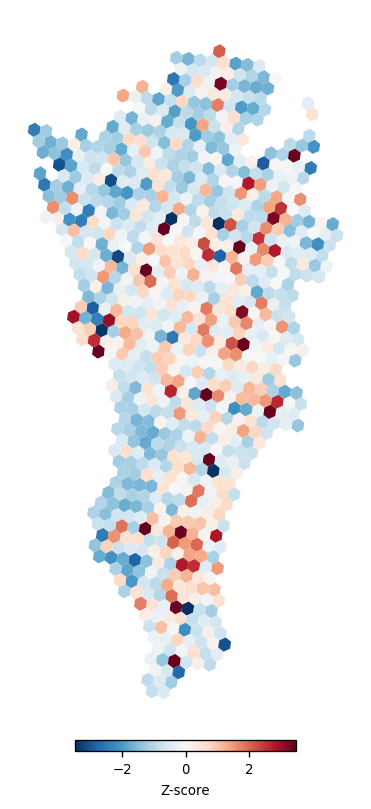

In [90]:
day_plot = "2023-04-21"

df_gdf_zscore = z_scores[[day_plot]].copy()
df_gdf_zscore["z_score"] = df_gdf_zscore[day_plot]
df_gdf_zscore_plot = df_gdf_zscore[["z_score"]]

vmax = 3.5
vmin =-vmax

gdf_map_zscore = gdf_h3.merge(df_gdf_zscore_plot, left_on="h3_index", right_on="hex_id", how="inner")

fig, ax = plt.subplots(figsize=(12,8), dpi=120)
gdf_map_zscore.plot(column="z_score", cmap="RdBu_r", legend=False, ax=ax, vmin=vmin, vmax=vmax)
sm = cm.ScalarMappable(cmap="RdBu_r", norm=plt.Normalize(vmin, vmax))
sm._A = []
cbar = fig.colorbar(sm, ax=ax, fraction=0.015, pad=0.01, orientation="horizontal")
cbar.set_label("Z-score", fontsize=8)
cbar.ax.tick_params(labelsize=8)
ax.axis("off");

**Figure 5.** Map of the Z-score of the Urban Space Usage Index across H3 hexagonal cells in Metro Manila on 30 April 2023. Warmer colors indicate higher-than-expected activity, showing a widespread increase across the metropolitan area.

We also provide an interactive map (Figure 6) to facilitate exploration of the full time series of Z-scores across the study area. This tool enables users to examine temporal dynamics at different locations, offering a more detailed and intuitive understanding of how activity patterns evolve over time.

In [6]:
from IPython.display import HTML
HTML('<iframe width="100%" height="800px" src="https://studio.foursquare.com/map/public/2ac659a1-4434-4964-8f1d-5d4c9b857a20/embed" frameborder="0" allowfullscreen></iframe>')

**Figure 6.** Interactive map of the Z-score of the Urban Space Usage Index across H3 hexagonal cells in the area of interest. The animation shows the day-by-day evolution of activity levels, with colors indicating relative intensity.

### 3.4 Spatial and Functional Characterization of Activity

To interpret the spatial distribution of activity, each hexagonal cell is associated with both land use and functional activity. For land use, we assign each hexagon a dominant category (e.g., residential, commercial, industrial, green areas), capturing the physical organization of urban space. In contrast, the functional layer is derived from POIs: for each hexagon, we count the number of POIs in different activity categories (e.g., schools, hospitals, parks, transport hubs, commercial venues).

Land-use and POI data are derived from OpenStreetMap (OSM) and accessed via Geofabrik extracts (https://download.geofabrik.de/asia/philippines.html
). To ensure temporal consistency with the mobility data, which refer to 2023, we use OSM snapshots from January 2023. © OpenStreetMap contributors, licensed under the Open Database License (ODbL).

In [77]:
# loading the land use shapefile
gdf_h3_landuse =  gpd.read_file(f"./land_usage/land_usage_h3_res8_metro_manila.gpkg")
gdf_h3_landuse_geo = gdf_h3_landuse.copy()

In [78]:
z_scores_baseline = z_scores.loc[:, "2023-04-03":"2023-04-11"]
z_scores_event = z_scores[HW_days]

activity_baseline = ts_USI.loc[:, "2023-04-03":"2023-04-11"]
activity_event = ts_USI[HW_days]

In [79]:
# Step 1: rename key
gdf_h3_landuse = gdf_h3_landuse.rename(columns={"h3_index": "hex_id"})

# Step 2: compute means and keep hex_id
z_base_mean = z_scores_baseline.mean(axis=1).to_frame("z_base_mean").reset_index()
z_event_mean = z_scores_event.mean(axis=1).to_frame("z_event_mean").reset_index()
act_base_mean = activity_baseline.mean(axis=1).to_frame("act_base_mean").reset_index()
act_event_mean = activity_event.mean(axis=1).to_frame("act_event_mean").reset_index()

# Step 3: merge everything
gdf_hex_scores_LU = (
    gdf_h3_landuse
    .merge(z_base_mean, on="hex_id", how="left")
    .merge(z_event_mean, on="hex_id", how="left")
    .merge(act_base_mean, on="hex_id", how="left")
    .merge(act_event_mean, on="hex_id", how="left")
)

gdf_hex_scores_LU = gdf_hex_scores_LU.dropna(subset=["z_base_mean"])

len(gdf_hex_scores_LU)

847

#### Land Use Analysis

We analyze how urban activity is distributed across different land-use categories during heatwave days, considering both **aggregate patterns** and **day-specific variations**.

At the aggregate level, the results show a **heterogeneous response** across land-use types. Commercial and green areas exhibit **positive average Z-scores** (0.19 and 0.40, respectively), indicating slightly higher activity relative to baseline levels. In contrast, construction (-0.69), water (-0.47), residential (-0.19), industrial (-0.17), and farmland (-0.22) areas show **negative Z-scores**, reflecting reduced activity.


These patterns suggest a **shift in activity toward specific types of environments** during heatwave conditions. In particular, the increase in commercial areas may reflect a preference for **indoor, climate-controlled spaces**, while the positive signal in green areas may be associated with their role as **relatively cooler or shaded environments**. Conversely, the decline in construction and industrial areas likely reflects reduced activity in **outdoor settings**, which are more exposed to extreme heat.


|   Land Use   | Z-score (event) | _I_ (event) | _I_ (baseline) |
|:------------:|:---------------:|:---------:|:------------:|
| commercial   | 0.19         | 0.00788        | 0.00784       |
| green        | 0.40         | 0.00537        | 0.00518       |
| construction | -0.69        | 0.00432        | 0.00508       |
| residential  | -0.19        | 0.00395        | 0.00428       |
| water        | -0.47        | 0.00284        | 0.00362       |
| industrial   | -0.17        | 0.00304        | 0.00359       |
| farmland     | -0.22        | 0.00047        | 0.00050       |

A day-by-day analysis reveals additional variability across heatwave events. Early heatwave days (April 20-23) are characterized by **positive or near-neutral Z-scores** in commercial and green areas, while later events (April 28 and 30) show a **more generalized decline** across most land-use categories.

|              | Z-score (agg) | Z-score (04-20) | zscore (04-21) | zscore (04-23) | zscore (04-28) | zscore (04-30) |
|:------------:|:------------:|:-------------------:|:-------------------:|:-------------------:|:-------------------:|:-------------------:|
| commercial   | 0.19         | 0.53                | 0.50                | 0.27                | 0.66                | -0.99               |
| construction | -0.69        | -0.23               | -1.02               | -0.13               | -0.94               | -1.15               |
| farmland     | -0.22        | 0.19                | -0.27               | 0.79                | -1.03               | -0.80               |
| green        | 0.40         | 0.64                | 0.68                | 0.29                | 0.90                | -0.49               |
| industrial   | -0.17        | 0.05                | -0.16               | 0.10                | -0.13               | -0.73               |
| residential  | -0.19        | 0.16                | -0.21               | 0.40                | -0.55               | -0.73               |
| water        | -0.47        | -0.16               | -0.59               | 0.06                | -0.69               | -0.95               |



Overall, while aggregate activity levels remain relatively stable, heatwave conditions are associated with a **redistribution of activity across land-use types**. This supports the interpretation that individuals adapt to extreme heat not by substantially reducing mobility, but by **shifting their activities toward more suitable areas.**





In [80]:
gdf_hex_scores_LU[gdf_hex_scores_LU["land_use"]!="other"].groupby("land_use")[["z_event_mean", "act_event_mean", "act_base_mean"]].mean(
    ).sort_values("act_base_mean", ascending=False).round({
        "z_event_mean": 2,   
        "act_event_mean": 5,    
        "act_base_mean": 5})

,z_event_mean,act_event_mean,act_base_mean
land_use,,,
commercial,0.19,0.00788,0.00784
green,0.40,0.00537,0.00518
construction,-0.69,0.00432,0.00508
residential,-0.19,0.00395,0.00428
water,-0.47,0.00284,0.00362
industrial,-0.17,0.00304,0.00359
farmland,-0.22,0.00047,0.00050


In [81]:
# --- Step 1: subset HW days ---
z_event = z_scores[HW_days].copy()

# --- Step 2: rename columns with dates ---
z_event.columns = [
    f"zscore ({pd.to_datetime(d).strftime('%Y-%m-%d')})"
    for d in z_event.columns
]

# --- Step 3: compute mean ---
z_event["zscore (agg)"] = z_event.mean(axis=1)

# --- Step 4: reset index to get hex_id ---
z_event = z_event.reset_index()  # assumes index = hex_id

# --- Step 5: merge with land use ---
df = gdf_h3_landuse[["hex_id", "land_use"]].merge(
    z_event, on="hex_id", how="left"
)

# --- Step 6: optional filter ---
df = df[df["land_use"] != "other"]

# --- Step 7: aggregate by land use ---
result = (
    df.groupby("land_use")
    .mean(numeric_only=True)
)

# --- Step 8: reorder columns (agg first) ---
cols = ["zscore (agg)"] + [c for c in result.columns if c != "zscore (agg)"]
result = result[cols]

result = result.round(2)
result

,zscore (agg),zscore (2023-04-20),zscore (2023-04-21),zscore (2023-04-23),zscore (2023-04-28),zscore (2023-04-30)
land_use,,,,,,
commercial,0.19,0.53,0.50,0.27,0.66,-0.99
construction,-0.69,-0.23,-1.02,-0.13,-0.94,-1.15
farmland,-0.22,0.19,-0.27,0.79,-1.03,-0.80
green,0.40,0.64,0.68,0.29,0.90,-0.49
industrial,-0.17,0.05,-0.16,0.10,-0.13,-0.73
residential,-0.19,0.16,-0.21,0.40,-0.55,-0.73
water,-0.47,-0.16,-0.59,0.06,-0.69,-0.95


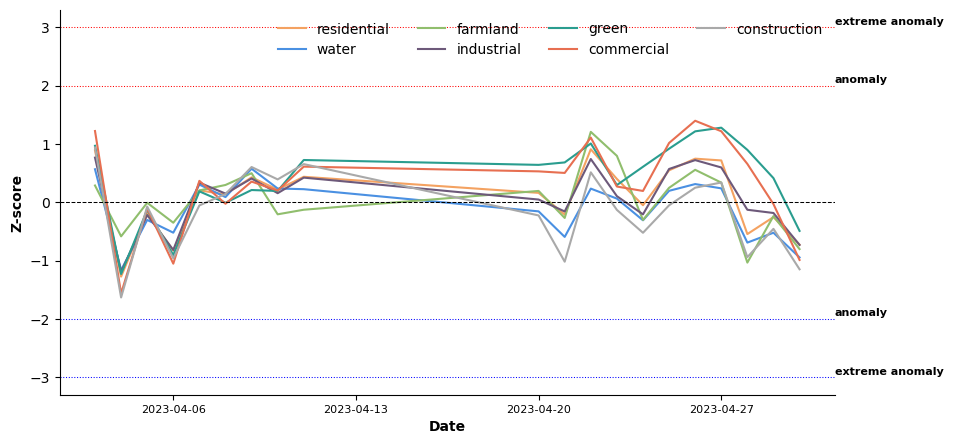

In [82]:
landuse_colors = {
"residential": "#F4A261",
"commercial": "#E76F51",
"industrial": "#6D597A",
"education": "blue",
"construction": "darkgrey",
"farmland": "#90BE6D",
"green": "#2A9D8F",
"water": "#4A90E2",
"other": "#EEEEEE"
}

fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(10, 5), sharex=False)

label_col = "land_use"

gdf_filtered = gdf_h3_landuse[gdf_h3_landuse[label_col]!="other"]
gdf_h3_landuse = gdf_h3_landuse[gdf_h3_landuse[label_col]!="none"]
gdf_filtered = gdf_filtered.dropna(subset=[label_col])

for category in gdf_filtered[label_col].unique():
    
    h3_in_category = set(gdf_filtered[gdf_filtered[label_col]==category]["hex_id"])
    z_scores_category = z_scores[z_scores.index.isin(h3_in_category)]

    x = pd.to_datetime(z_scores_category.columns)
    y = z_scores_category.values
    
    # --- Plot all series at once  ---
    #ax.plot(x, y.T, color="grey", alpha=0.15, linewidth=0.5)
    if label_col == "land_use":
        color = landuse_colors[category]
    else:
        color = poi_colors[category]
        
    ax.plot(z_scores_category.mean(), label=category, color=color)


# --- Event window shading ---
'''
ax.axvspan(EVENT_START, EVENT_END, color="orange", alpha=0.1, linewidth=0)
ax.text(EVENT_START, 0.05, "Republic Day", transform=ax.get_xaxis_transform() ,fontsize=9,
        weight="bold", va="top", ha="right", bbox=dict(
    facecolor="orange", edgecolor="none", boxstyle="round,pad=0.3", alpha=0.25))
'''
plt.legend(ncol=4)

x_lims = ax.set_xlim()

# --- Anomaly thresholds ---

for anomaly_th, anomaly_label in zip([2, 3], ["anomaly", "extreme anomaly"]):
    ax.axhline(anomaly_th, c="red", linewidth=.75, linestyle=":")
    ax.axhline(-anomaly_th, c="blue", linewidth=.75, linestyle=":")
    
    # Adding labels for anomalies
    plt.text(x_lims[1], anomaly_th + 0.1, anomaly_label, ha="left", va="center", weight=600, size=8)
    plt.text(x_lims[1], -anomaly_th + 0.1, anomaly_label, ha="left", va="center", weight=600, size=8)


ax.tick_params(axis='x', labelsize=8)
ax.xaxis.set_major_locator(mdates.DayLocator(interval=7))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
ax.set_xlabel("Date", weight=600)
ax.set_ylabel("Z-score", weight=600)
ax.axhline(0, c="k", linewidth=.75, linestyle="--");

#### Functional (POI-Based) Analysis


We then examine activity across **functional layers derived from points of interest (POIs)**, capturing how different types of urban services and destinations are affected by heatwaves.
At the aggregate level, most categories exhibit **negative Z-scores**, indicating a reduction in activity relative to the baseline. The largest decreases are observed for **airports (-1.06), highways (-0.50), train stations (-0.43), and universities (-0.39)**. Other categories, including hospitals (-0.32), tourism (-0.28), restaurants (-0.24), shops (-0.25), schools (-0.25), and offices (-0.21), also show **moderate decreases**.

In contrast, **malls (0.11) and parks (0.14)** exhibit slightly positive Z-scores, indicating **stable or marginally increased activity** during heatwave days. These patterns suggest a **shift toward specific types of environments** under extreme heat conditions. The increase in mall-related activity may reflect a preference for **indoor and climate-controlled space**s, while parks may serve as **relatively cooler or shaded areas**.

|    POI layer   | Z-score (event) | _I_ (event) | _I_ (baseline) |
|:--------------:|:------------:|:--------------:|:-------------:|
| train stations | -0.43        | 0.00864        | 0.00948       |
| malls          | 0.11         | 0.00798        | 0.00806       |
| universities   | -0.39        | 0.00680        | 0.00728       |
| parks          | 0.14         | 0.00751        | 0.00725       |
| tourism        | -0.28        | 0.00640        | 0.00704       |
| highways       | -0.50        | 0.00607        | 0.00696       |
| hospitals      | -0.32        | 0.00546        | 0.00588       |
| offices        | -0.21        | 0.00522        | 0.00569       |
| restaurants    | -0.24        | 0.00505        | 0.00549       |
| schools        | -0.25        | 0.00484        | 0.00523       |
| airports       | -1.06        | 0.00357        | 0.00494       |
| shops          | -0.25        | 0.00453        | 0.00494       |

The day-by-day analysis reveals **consistent patterns across events**. Early heatwave days (April 20–23) show **slightly positive deviations** for several categories, including malls and parks. However, later heatwave days (April 28 and 30) are associated with a **more pronounced decline across nearly all categories**, including those that previously showed resilience.



|              | Z-score (agg) | Z-score (04-20) | zscore (04-21) | zscore (04-23) | zscore (04-28) | zscore (04-30) |
|:------------:|:------------:|:-------------------:|:-------------------:|:-------------------:|:-------------------:|:-------------------:|
| highways       | -0.50               | -0.08               | -0.61               | 0.06                | -0.65               | -1.23 |
| airports       | -1.06               | -0.66               | -1.09               | -0.89               | -0.87               | -1.80 |
| hospitals      | -0.32               | 0.05                | -0.24               | 0.14                | -0.42               | -1.13 |
| malls          | 0.11                | 0.29                | 0.30                | 0.28                | 0.48                | -0.81 |
| offices        | -0.21               | 0.12                | -0.14               | 0.16                | -0.24               | -0.96 |
| restaurants    | -0.24               | 0.09                | -0.22               | 0.19                | -0.35               | -0.92 |
| schools        | -0.25               | 0.12                | -0.25               | 0.22                | -0.40               | -0.93 |
| shops          | -0.25               | 0.10                | -0.25               | 0.23                | -0.42               | -0.91 |
| tourism        | -0.28               | 0.11                | -0.19               | 0.00                | -0.21               | -1.12 |
| train stations | -0.43               | 0.06                | -0.43               | -0.20               | -0.24               | -1.35 |
| universities   | -0.39               | -0.06               | -0.29               | -0.15               | -0.06               | -1.39 |
| parks          | 0.14                | 0.64                | 0.59                | -0.07               | 0.68                | -1.16 |







Overall, the results reinforce the findings from the land-use analysis: while aggregate activity levels remain relatively stable, heatwave conditions lead to a **redistribution of activity toward environments that are more compatible with extreme heat exposure**.


In [83]:
layers_POI = ['is_highway', 'n_airports', 'n_hospitals', 'n_malls', 'n_offices', 'n_restaurants', 'n_schools',
            'n_shops', 'n_tourism', 'n_train_stations', 'n_universities', 'n_parks']

In [84]:
rows = []

for layer in layers_POI:
    avg_scores_in_layer = (
        gdf_hex_scores_LU[gdf_hex_scores_LU[layer] > 0]
        [["z_event_mean", "act_event_mean", "act_base_mean"]]
        .mean()
    )
    
    # Convert to dict and add layer name
    row = avg_scores_in_layer.to_dict()
    row["layer"] = layer
    
    rows.append(row)

# Create DataFrame
pd.DataFrame(rows).set_index("layer").sort_values("act_base_mean", ascending=False).round({
        "z_event_mean": 2,   
        "act_event_mean": 5,    
        "act_base_mean": 5})

,z_event_mean,act_event_mean,act_base_mean
layer,,,
n_train_stations,-0.43,0.00864,0.00948
n_malls,0.11,0.00798,0.00806
n_universities,-0.39,0.00680,0.00728
n_parks,0.14,0.00751,0.00725
n_tourism,-0.28,0.00640,0.00704
is_highway,-0.50,0.00607,0.00696
n_hospitals,-0.32,0.00546,0.00588
n_offices,-0.21,0.00522,0.00569
n_restaurants,-0.24,0.00505,0.00549


In [85]:
rows = []

for layer in layers_POI:
    # hexes belonging to this layer
    hex_ids = gdf_hex_scores_LU.loc[
        gdf_hex_scores_LU[layer] > 0, "hex_id"
    ]

    # --- daily z-scores from ORIGINAL dataframe ---
    z_daily = z_scores.loc[hex_ids, HW_days]

    # --- compute daily means ---
    daily_means = z_daily.mean(axis=0)

    # --- format column names (remove 00:00:00) ---
    daily_means.index = [
        f"zscore ({pd.to_datetime(d).strftime('%Y-%m-%d')})"
        for d in daily_means.index
    ]

    # --- aggregate mean across HW days ---
    agg_mean = z_daily.mean(axis=1).mean()

    # --- build row ---
    row = daily_means.to_dict()
    row["zscore (agg)"] = agg_mean
    row["layer"] = layer

    rows.append(row)

# --- final table ---
result = pd.DataFrame(rows).set_index("layer")

# --- reorder columns ---
cols = ["zscore (agg)"] + [c for c in result.columns if c != "zscore (agg)"]
result = result[cols]

# --- round ---
result = result.round(2)

result

,zscore (agg),zscore (2023-04-20),zscore (2023-04-21),zscore (2023-04-23),zscore (2023-04-28),zscore (2023-04-30)
layer,,,,,,
is_highway,-0.50,-0.08,-0.61,0.06,-0.65,-1.23
n_airports,-1.06,-0.66,-1.09,-0.89,-0.87,-1.80
n_hospitals,-0.32,0.05,-0.24,0.14,-0.42,-1.13
n_malls,0.11,0.29,0.30,0.28,0.48,-0.81
n_offices,-0.21,0.12,-0.14,0.16,-0.24,-0.96
n_restaurants,-0.24,0.09,-0.22,0.19,-0.35,-0.92
n_schools,-0.25,0.12,-0.25,0.22,-0.40,-0.93
n_shops,-0.25,0.10,-0.25,0.23,-0.42,-0.91
n_tourism,-0.28,0.11,-0.19,0.00,-0.21,-1.12


Text(0.5, 0, 'Date')

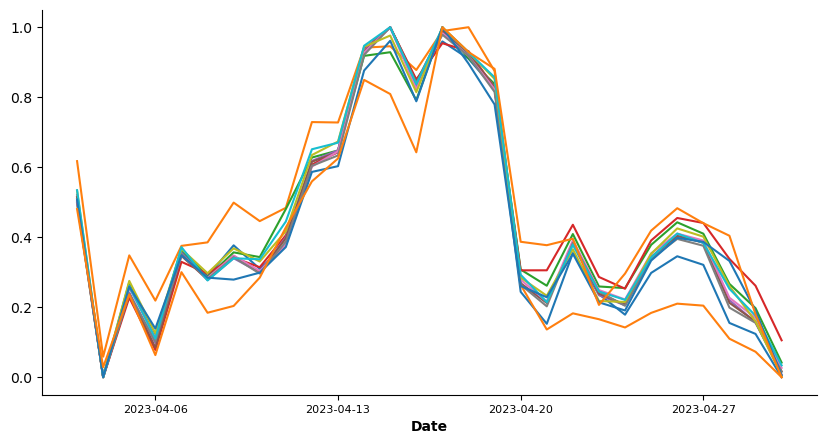

In [86]:
fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(10, 5), sharex=False)

for layer in layers_POI:
    
    h3_in_layer = set(gdf_h3_landuse[gdf_h3_landuse[layer]>0]["hex_id"])
    activity_norm_layer = ts_USI[ts_USI.index.isin(h3_in_layer)]
    
    x = pd.to_datetime(activity_norm_layer.columns)
    y = min_max_normalize_range(activity_norm_layer.mean().values)
    
    ax.plot(x,y, label=layer)

'''
ax.axvspan(EVENT_START, EVENT_END, color="orange", alpha=0.1, linewidth=0)
ax.text(EVENT_START, 0.05, "Republic Day", transform=ax.get_xaxis_transform() ,fontsize=9,
        weight="bold", va="top", ha="right", bbox=dict(
    facecolor="orange", edgecolor="none", boxstyle="round,pad=0.3", alpha=0.25))
'''

ax.tick_params(axis='x', labelsize=8)
ax.xaxis.set_major_locator(mdates.DayLocator(interval=7))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
ax.set_xlabel("Date", weight=600)
#ax.set_ylabel(f"Avg. I of layer {layer}", weight=600)
#ax.axhline(0, c="k", linewidth=.75, linestyle="--")

#ax.set_xlim(pd.to_datetime("2023-10-28"), pd.to_datetime("2023-10-31"))

In [87]:
df_hex_animation = (
    z_scores.reset_index()  # bring hex_id out of index
      .melt(id_vars="hex_id", var_name="timestamp", value_name="z_score"))

# Ensure timestamp is datetime
df_hex_animation["timestamp"] = pd.to_datetime(df_hex_animation["timestamp"])
df_hex_animation["timestamp"] = df_hex_animation["timestamp"].dt.strftime("%Y-%m-%dT%H:%M:%S")
df_hex_animation = df_hex_animation.round(2)
print(df_hex_animation.head())

df_hex_animation.to_csv("hex_timeseries_data_heatwaves_april.csv", index=False)

            hex_id            timestamp  z_score
0  88694e5201fffff  2023-04-03T00:00:00     0.03
1  88694e5203fffff  2023-04-03T00:00:00     1.01
2  88694e5205fffff  2023-04-03T00:00:00    -1.30
3  88694e5207fffff  2023-04-03T00:00:00     0.06
4  88694e5209fffff  2023-04-03T00:00:00     1.14


In [88]:
# robustness test vs baseline choice


rows = []

test_baselines = [
    ("2023-04-03", "2023-04-11"), 
    ("2023-04-05", "2023-04-11"), 
    ("2023-04-07", "2023-04-11"), 
]

for base_start, base_end in test_baselines:

    # --- baseline stats ---
    baseline = ts_USI.loc[:, base_start:base_end]
    baseline_mean = baseline.mean(axis=1)
    baseline_std = baseline.std(axis=1)

    # --- compute z-scores ---
    z_scores_test = ts_USI.sub(baseline_mean, axis=0).div(baseline_std, axis=0)

    # --- HW daily mean across hexes ---
    hw_means = z_scores_test[HW_days].mean(axis=0)

    # --- clean column names ---
    hw_means.index = [
        f"zscore ({pd.to_datetime(d).strftime('%Y-%m-%d')})"
        for d in hw_means.index
    ]

    # --- aggregate mean ---
    agg_mean = hw_means.mean()

    # --- Mann-Whitney U test ---
    z_HW = z_scores_test[HW_days].mean().values
    z_non_HW = (
        z_scores_test
        .drop(columns=HW_days)
        .loc[:, "2023-04-20":]
        .mean()
        .values
    )

    stat, p = mannwhitneyu(z_HW, z_non_HW, alternative="less")

    # permutation test
    z_all = np.concatenate([z_HW, z_non_HW])
    n_HW = len(z_HW)
    T_all = []
    for comb in itertools.combinations(z_all, n_HW):
        T_all.append(np.mean(comb))
        
    T_all = np.array(T_all)
    
    p_exact = np.mean(T_all <= z_HW.mean())

    # --- row label ---
    label = f"baseline_{base_start}_to_{base_end}"

    # --- store row ---
    row = hw_means.to_dict()
    row["zscore (agg)"] = agg_mean
    row["MWU_stat"] = stat
    row["MWU_pvalue"] = p
    row["Permutation_pvalue"] = p_exact
    row["baseline"] = label

    rows.append(row)

# --- final dataframe ---
df_test_baselines = pd.DataFrame(rows).set_index("baseline")

# --- reorder columns ---
cols = (
    ["zscore (agg)"] +
    [c for c in df_test_baselines.columns if "zscore (" in c and c != "zscore (agg)"] +
    ["MWU_stat", "MWU_pvalue", "Permutation_pvalue"]
)
df_test_baselines = df_test_baselines[cols]

# --- rounding ---
z_cols = [c for c in df_test_baselines.columns if c.startswith("zscore")]
df_test_baselines = df_test_baselines.round({
    **{col: 2 for col in z_cols},   # all zscore columns
    "MWU_stat": 2,
    "MWU_pvalue": 4,
    "Permutation_pvalue": 4
})

df_test_baselines

,zscore (agg),zscore (2023-04-20),zscore (2023-04-21),zscore (2023-04-23),zscore (2023-04-28),zscore (2023-04-30),MWU_stat,MWU_pvalue,Permutation_pvalue
baseline,,,,,,,,,
baseline_2023-04-03_to_2023-04-11,-0.19,0.13,-0.20,0.30,-0.41,-0.79,5.0,0.0411,0.0303
baseline_2023-04-05_to_2023-04-11,-0.33,0.09,-0.33,0.27,-0.57,-1.12,5.0,0.0411,0.0281
baseline_2023-04-07_to_2023-04-11,-0.89,-0.31,-0.89,-0.06,-1.20,-1.98,5.0,0.0411,0.0325


## 4. Conclusions and Key Findings

This analysis quantifies the impact of heatwaves on urban activity patterns in Metro Manila using anonymized mobility data and the Urban Space Usage Index.

The main findings are:

**1.** Aggregate activity levels remain relatively stable during heatwave days, with only modest deviations from baseline conditions. Z-scores are generally close to zero, with three out of five heatwave days exhibiting negative values, and an overall slight but statistically significant reduction compared to non-heatwave days.


**2.** Heatwaves induce a redistribution of activity rather than large aggregate changes. While overall activity levels are only marginally affected, land-use and POI-based analyses reveal systematic shifts in how urban space is used.


**3.** Activity shifts toward environments more compatible with extreme heat exposure. In particular, commercial areas and malls show stable or slightly increased activity, as do green areas, potentially reflecting their role as relatively cooler or shaded environments.


**4.**  Heatwaves exhibit a distinct impact compared to other types of events. While large planned events (e.g., Republic Day) and sudden shocks (e.g., earthquakes) produce strong and immediate changes in both aggregate activity and spatial visitation patterns, heatwaves generate a weaker aggregate signal but a clear pattern of spatial and functional redistribution.

Overall, these results suggest that while the proposed framework and the **Urban Space Usage Index may not detect strong anomalies** for heatwaves at the aggregate level, **it is well suited to uncovering underlying patterns** of spatial and functional redistribution.


## Limitations
This analysis is subject to some limitations. Mobility data may not fully represent the entire population, as it depends on smartphone usage and data coverage. In addition, spatial aggregation into H3 cells may smooth local variations.